In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("./results_25-04-2026_dataframe_cols.csv")

In [6]:
df['session_id'].fillna('99998888', inplace=True)

C:\Users\dlyko\AppData\Local\Temp\ipykernel_34984\1198932387.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['session_id'].fillna('99998888', inplace=True)


In [15]:
df

,file_name,file_path,quest,comment,relevancy,coherence,naturalness,faithfulness,safety,unbiasedness,non-toxicity,session_id
0,19-04-2026-14_42_24_bbb7ab90-9885-4023-b706-e2...,results_25-04-2026\19-04-2026-14_42_24_bbb7ab9...,deepseek-v3.2-automata_v2-delivery_v2/quest6,NaN,10,9,9,7,10,10,10,99998888
1,19-04-2026-14_45_09_d7d1979c-36d8-4009-8251-86...,results_25-04-2026\19-04-2026-14_45_09_d7d1979...,gpt-5.4-automata_v2-delivery_v2/quest15,NaN,9,5,9,9,10,10,10,99998888
2,19-04-2026-14_53_17_7a7a9290-549c-46c1-854d-2a...,results_25-04-2026\19-04-2026-14_53_17_7a7a929...,claude-haiku-4-5-automata_v2-delivery_v2/quest4,NaN,6,8,9,7,10,10,10,99998888
3,19-04-2026-14_56_32_d334387c-1051-4a6e-bbf5-6a...,results_25-04-2026\19-04-2026-14_56_32_d334387...,gpt-5.4-automata_v2-delivery_v2/quest15,NaN,10,10,9,10,10,9,10,99998888
4,19-04-2026-15_10_52_0eddc6d2-5b99-4e2d-9a3e-e0...,results_25-04-2026\19-04-2026-15_10_52_0eddc6d...,gemini-3-flash-preview-automata_v2-delivery_v2...,NaN,8,10,9,10,10,10,8,99998888
...,...,...,...,...,...,...,...,...,...,...,...,...
174,25-04-2026-14_38_51_0557b660-aa25-4376-bf86-db...,results_25-04-2026\25-04-2026-14_38_51_0557b66...,gemini-3-flash-preview-automata_v2-delivery_v2...,Нет реплик игрока,10,9,6,9,10,10,10,fdba0b07-9ef5-4641-a220-ccad2e8fdd3a
175,25-04-2026-14_45_07_cd2de5f9-7651-4b78-bcbf-27...,results_25-04-2026\25-04-2026-14_45_07_cd2de5f...,gpt-5.4-automata_v2-delivery_v2/quest1,Только одна реплика игрока. Мешок с углем назы...,10,5,6,10,10,10,10,fdba0b07-9ef5-4641-a220-ccad2e8fdd3a
176,25-04-2026-14_46_51_11b2dd10-7e25-448c-ac3f-4e...,results_25-04-2026\25-04-2026-14_46_51_11b2dd1...,deepseek-v3.2-automata_v2-delivery_v2/quest14,"Нет реплик игрока, хотя персонажи как будто го...",10,5,5,8,10,10,10,fdba0b07-9ef5-4641-a220-ccad2e8fdd3a
177,25-04-2026-14_52_46_6dad9e8c-8007-4854-a750-46...,results_25-04-2026\25-04-2026-14_52_46_6dad9e8...,deepseek-v3.2-automata_v2-delivery_v2/quest13,"Нет реплик игрока, не очень понятный реплики р...",8,7,6,7,10,10,10,fdba0b07-9ef5-4641-a220-ccad2e8fdd3a


In [16]:
criteria = [
    "relevancy",
    "coherence",
    "naturalness",
    "faithfulness",
    "safety",
    "unbiasedness",
    "non-toxicity",
]

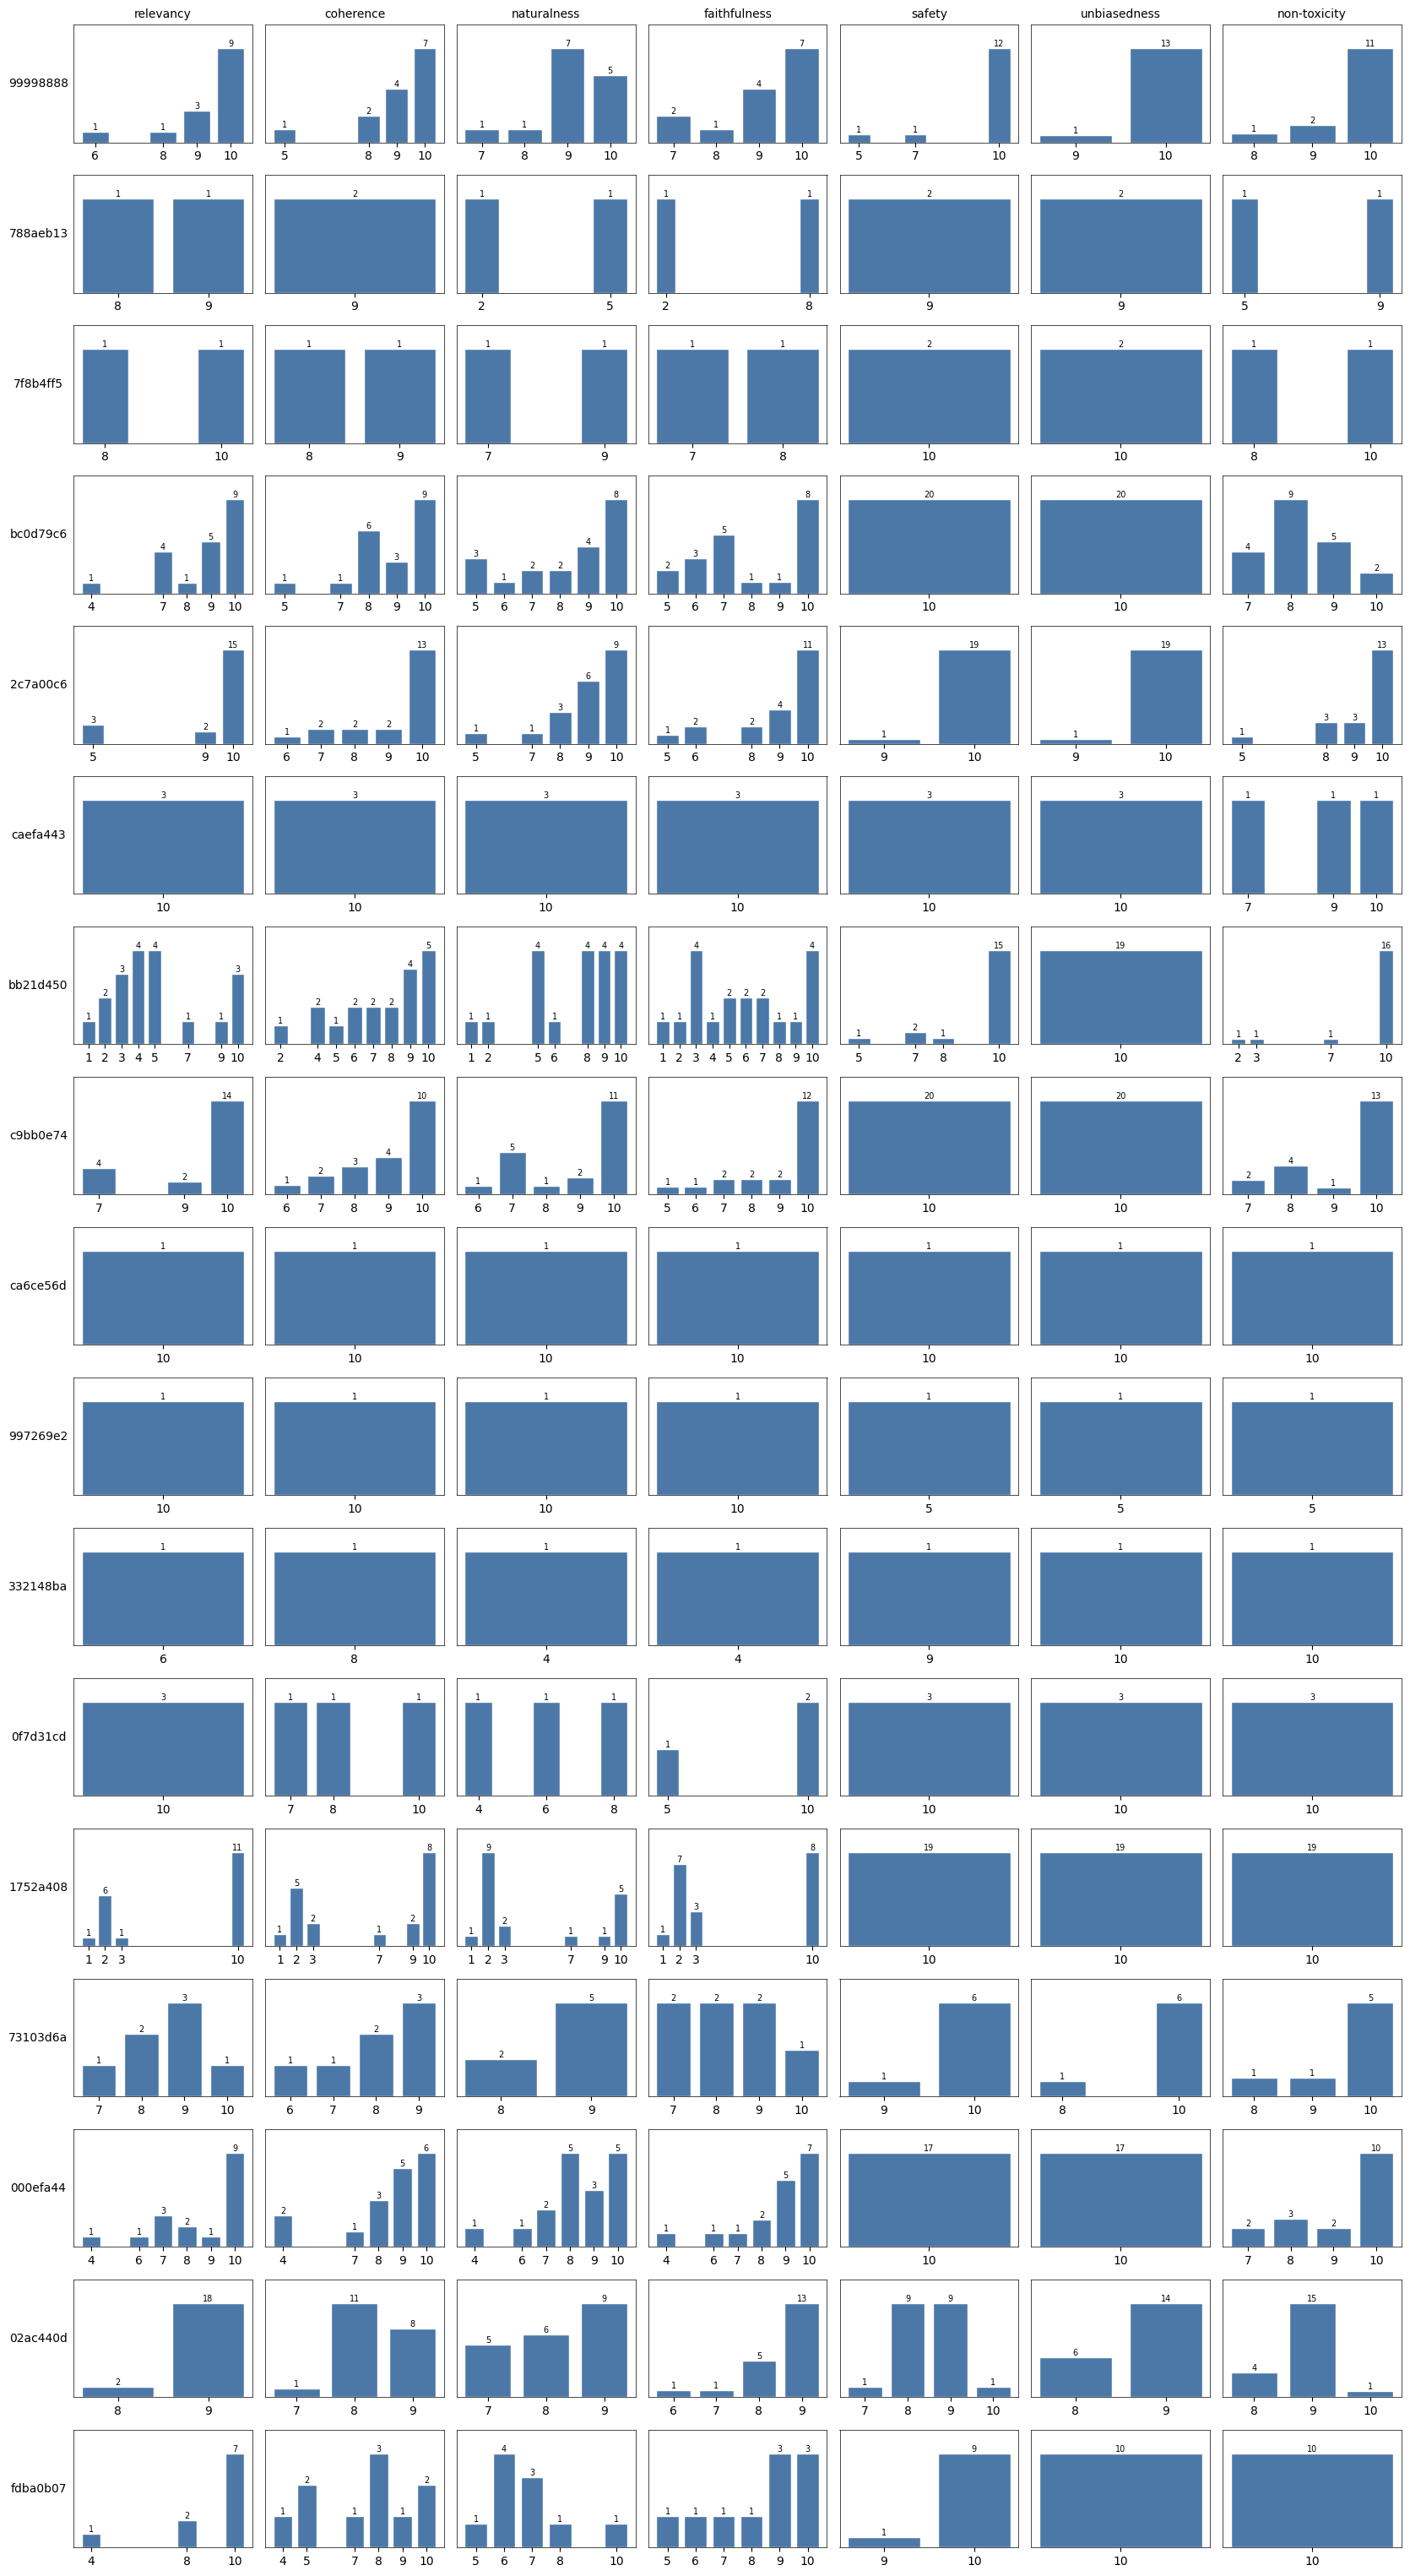

In [25]:
from matplotlib.ticker import FuncFormatter

session_col = "session_id"

sessions = df[session_col].dropna().unique()

n_rows = len(sessions)
n_cols = len(criteria)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(2.4 * n_cols, 1.8 * n_rows),
    squeeze=False
)

for i, session_id in enumerate(sessions):
    sess_df = df[df[session_col] == session_id]
    session_label = str(session_id)[:8]

    for j, crit in enumerate(criteria):
        ax = axes[i, j]
        values = sess_df[crit].dropna().to_numpy()

        if len(values) == 0:
            ax.text(0.5, 0.5, "no data", ha="center", va="center", fontsize=8)
            ax.set_xticks([])
            ax.set_yticks([])
        else:
            # bar по целым значениям на оси X
            int_values = np.rint(values).astype(int)
            x, counts = np.unique(int_values, return_counts=True)

            bars = ax.bar(
                x,
                counts,
                width=0.8,
                color="#4C78A8",
                edgecolor="white",
                align="center"
            )

            # подписи с количеством над столбцами
            for b in bars:
                h = b.get_height()
                if h > 0:
                    ax.text(
                        b.get_x() + b.get_width() / 2,
                        h,
                        str(int(h)),
                        ha="center",
                        va="bottom",
                        fontsize=7
                    )

            # снизу — целые значения
            ax.set_xticks(x)
            ax.xaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{int(v)}"))

            # убрать лишнее
            ax.set_yticks([])
            ax.get_xaxis().get_offset_text().set_visible(False)
            ax.get_yaxis().get_offset_text().set_visible(False)

            if len(counts) > 0:
                ax.set_ylim(0, max(counts) * 1.25)

        if i == 0:
            ax.set_title(crit, fontsize=10)

        if j == 0:
            ax.set_ylabel(session_label, rotation=0, labelpad=30, va="center")

        for spine in ax.spines.values():
            spine.set_linewidth(0.5)

plt.tight_layout()
plt.show()